# Unsupervised Learning on Graphs

This notebook explores a specific type of unsupervised representation learning technique with graph-structured data. In particular this will be a **contrastive learning** model, where an encoder is trained to be contrastive and distinguish between representations that are dependent on each other and those that are not.

A possible approach to obtain such an encoder is to train it to maximise the **local mutual information** between a global representation of the graph and its node representations. 

In [69]:
import torch
import torch.nn as nn
import torch_geometric.nn as pygnn
import torch.nn.functional as F
from typing import Literal 
import io

In [ ]:
class GCNNetwork(nn.Module):

    def __init__(self, in_channels, hidden_channels, out_channels, **kwargs):
        super().__init__(**kwargs)


        self.encoder = nn.Sequential(
            nn.Linear(in_features=in_channels,out_features=hidden_channels),
            # torch.nn.BatchNorm1d(hidden_channels, momentum=0.1),
            nn.PReLU()
        )

        self.convs = pygnn.GCN(in_channels=hidden_channels, out_channels=hidden_channels, hidden_channels=hidden_channels, num_layers=1, act='prelu')

        self.decoder = nn.Sequential(
            nn.Linear(in_features=hidden_channels,out_features=out_channels),
            torch.nn.BatchNorm1d(hidden_channels, momentum=0.1),
            nn.PReLU(),
        )

        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x, edge_index):
        x = self.encoder(x)
        x = self.convs(x, edge_index)
        x = self.dropout(x)
        x = self.decoder(x)

        return x
    
    def get_negative_example(self, x):
        # Shuffles along the node dimension (node i gets features of j)
        n = x.shape[-2]
        perm = torch.randperm(n)
        x_ = x.clone()
        return x_[perm]

In [100]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

embeddings = Planetoid(root=f'data/', name='cora', transform=NormalizeFeatures())

In [101]:
graph = embeddings[0]

In [ ]:
model = GCNNetwork(in_channels=1433, hidden_channels=64, out_channels=64)
model_untrained = GCNNetwork(in_channels=1433, hidden_channels=64, out_channels=64)

In [103]:
class Discriminator(nn.Module):
    def __init__(self, dim):
        super(Discriminator, self).__init__()
        self.fn = nn.Bilinear(dim, dim, 1)

    def forward(self, h, c):
        c_x = c.expand_as(h).contiguous()
        sc = self.fn(h, c_x).squeeze(1)
        return sc

In [104]:
disc = Discriminator(dim=64)

In [105]:
def get_graph_summary(x):
    return torch.sigmoid(x.mean(dim=-2))

In [106]:
def contrastive_loss(H, H_tilde, s, D: Discriminator):
    embeddings = torch.cat((H, H_tilde), dim=0)
    return F.binary_cross_entropy_with_logits(
        D(embeddings, s),
        torch.cat((torch.ones(H.shape[0], device=s.device), 
                   torch.zeros(H.shape[0], device=s.device)))
    )

In [107]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
disc = disc.to(device)
graph = graph.to(device)

In [108]:
optim = torch.optim.Adam([{'params': model.parameters(), 'lr': 0.0005},
                          {'params': disc.parameters(), 'lr': 0.0005}])

In [109]:
epochs = 1000
losses = []
for e in range(epochs):
    model.train()
    disc.train()
    optim.zero_grad()

    h = model(graph.x, graph.edge_index)
    h_tilde = model(model.get_negative_example(graph.x), graph.edge_index)

    s = get_graph_summary(h)

    loss = contrastive_loss(H=h, H_tilde=h_tilde, s=s, D=disc)

    loss.backward()
    optim.step()
    if e %50 == 0:
        print(e, loss.item())
    losses.append(loss.item())

0 0.8447138667106628
50 0.6110435724258423
100 0.3256293833255768
150 0.17386549711227417
200 0.10573673993349075
250 0.07209333032369614
300 0.06366807222366333
350 0.04947221279144287
400 0.040279172360897064
450 0.041129231452941895
500 0.032030168920755386
550 0.03481712192296982
600 0.02586548961699009
650 0.021467454731464386
700 0.025252917781472206
750 0.017966479063034058
800 0.021210242062807083
850 0.01588316261768341
900 0.017915690317749977
950 0.015145200304687023


In [184]:
embeddings = model(graph.x, graph.edge_index).detach()
embeddings_untrained = model_untrained(graph.x, graph.edge_index).detach()

train_embs = embeddings[graph.train_mask]
train_embs_untrained = embeddings_untrained[graph.train_mask]
train_labels = graph.y[graph.train_mask]


val_embs = embeddings[graph.val_mask]
val_embs_untrained = embeddings_untrained[graph.val_mask]
val_labels = graph.y[graph.val_mask]

In [185]:
import matplotlib.pyplot as plt

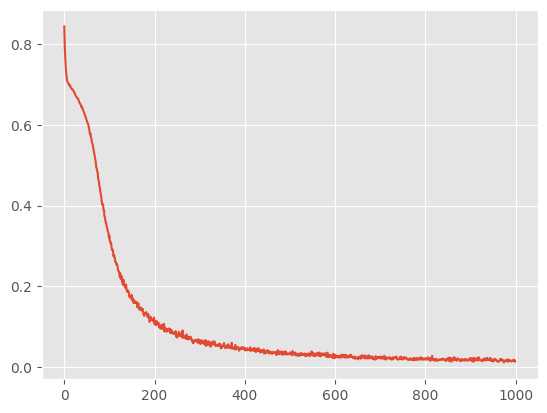

In [186]:
plt.plot(losses)

# Supervised Validation

We can now use the embeddings obtained with the unsupervised approach and apply a **linear** classifier on them. 

In [ ]:
class LinearClassifier(nn.Module):
    def __init__(self, features, classes):
        super().__init__()
        self.lin = nn.Linear(features, classes)


    def forward(self, x):
        return self.lin(x)
    

class EarlyStopper():
    def __init__(self, patience, mode: Literal['max', 'min']='max'):
        self.patience = patience
        self.mode = mode
        self.best = float('-inf') if mode == 'max'else float('inf')
        self.weights_buffer = io.BytesIO()
        self.best_iter = -1
        self.global_iter = 0
        self.count = 0

    def _is_better(self, new_value):
        if self.mode == 'max':
            return new_value > self.best 
        return new_value < self.best 

    def __call__(self, new_value, model):
        
        if self._is_better(new_value):
            self.best = new_value
            self.best_iter = self.global_iter
            self.count = 0
            self.weights_buffer.seek(0)
            self.weights_buffer.truncate(0)
            torch.save(model.state_dict(), self.weights_buffer)
        else:
            self.count += 1
        self.global_iter += 1
        
        if self.count > self.patience:
            return True
        return False
        
    def set_best_weights(self, model):
        self.weights_buffer.seek(0)
        model.load_state_dict(torch.load(self.weights_buffer))



In [188]:
def accuracy(X, y, model):
    return (torch.argmax(torch.nn.functional.softmax(model(X), dim=-1),dim=-1) == y).to(torch.float32).mean().cpu().numpy()

In [189]:

    
# classifier = LinearClassifier(64,7)
# classifier = classifier.to(device)

# early_stopping = EarlyStopper(patience=100, mode='min')

In [190]:
# opt = torch.optim.Adam(classifier.parameters(), lr=0.0008)
# loss_fn = nn.CrossEntropyLoss()

In [191]:
def fit_linear_classifier(classifier, train_embs, train_labels, val_embs, val_labels, lr):

    # classifier = LinearClassifier(64,7)
    classifier = classifier.to(device)

    opt = torch.optim.Adam(classifier.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    early_stopping = EarlyStopper(patience=100, mode='max')

    classifier_train_loss = []
    classifier_val_loss = [] 

    classifier_train_acc = []
    classifier_val_acc = [] 

    for epoch in range(5000):
        classifier.train()
        opt.zero_grad()

        logits = classifier(train_embs)

        loss = loss_fn(logits, train_labels)
        loss.backward()
        opt.step()

        classifier_train_loss.append(loss.item())
        classifier_train_acc.append(accuracy(X=train_embs, y=train_labels, model=classifier))
        # eval 
        with torch.no_grad():
            classifier.eval()

            logits = classifier(val_embs)
            val_loss = loss_fn(logits, val_labels)
            classifier_val_loss.append(val_loss.item())
            classifier_val_acc.append(accuracy(X=val_embs, y=val_labels, model=classifier))

            if early_stopping(new_value=classifier_val_acc[-1], model=classifier):
                early_stopping.set_best_weights(model=classifier)
                print(f'Early stopped at {epoch}')
                
                break


    return classifier_train_loss, classifier_train_acc, classifier_val_loss, classifier_val_acc, early_stopping.best_iter
        # print(loss.item())

In [192]:
train_embs.shape

torch.Size([140, 64])

In [193]:
classifier = LinearClassifier(64,7)
res_trained = fit_linear_classifier(classifier=classifier, 
                                    train_embs=train_embs,
                                    train_labels=train_labels,
                                    val_embs=val_embs,
                                    val_labels=val_labels,
                                    lr=0.0008)

classifier2 = LinearClassifier(1433,7)
res_untrained = fit_linear_classifier(classifier=classifier2, 
                                    train_embs=graph.x[graph.train_mask],
                                    train_labels=train_labels,
                                    val_embs=graph.x[graph.val_mask],
                                    val_labels=val_labels,
                                    lr=0.0001)

classifier_train_loss, classifier_train_acc, classifier_val_loss, classifier_val_acc, best_iter = res_trained
classifier_train_loss_u, classifier_train_acc_u, classifier_val_loss_u, classifier_val_acc_u, best_iter_u = res_untrained

Early stopped at 673
Early stopped at 809


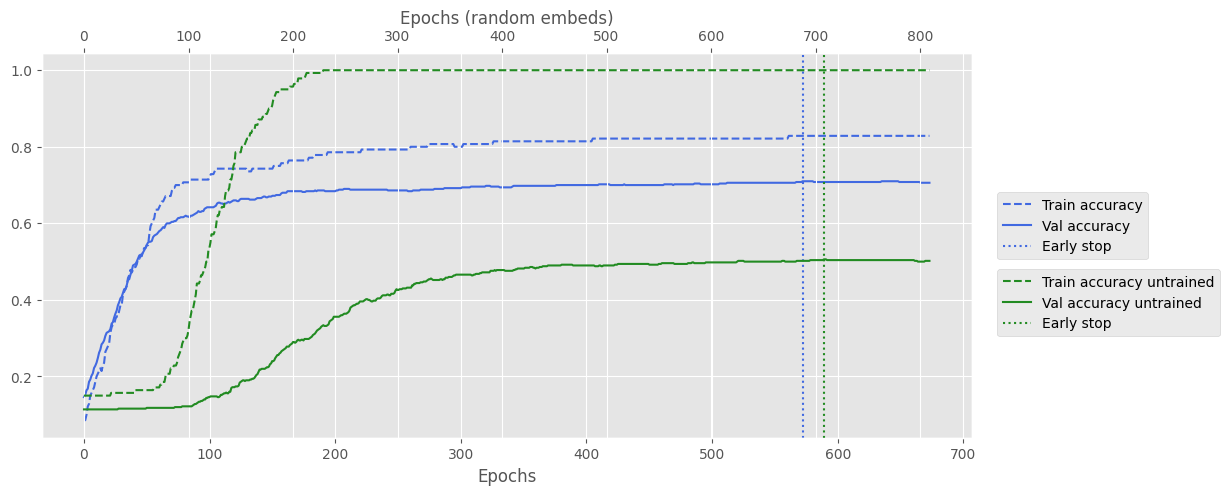

In [194]:
fig, ax = plt.subplots(figsize=(12, 5))


ax.plot(classifier_train_acc, label='Train accuracy', color='royalblue', linestyle='dashed')
ax.plot(classifier_val_acc, label='Val accuracy', color='royalblue', linestyle='solid')

ax1 = ax.twiny()
ax1.plot(classifier_train_acc_u, label='Train accuracy untrained', color='forestgreen', linestyle='dashed')
ax1.plot(classifier_val_acc_u, label='Val accuracy untrained', color='forestgreen', linestyle='solid')
ax1.set_xlabel('Epochs (random embeds)')
ax.set_xlabel('Epochs')

ax.axvline(x=best_iter, linestyle='dotted', label=f'Early stop', color='royalblue')
ax1.axvline(x=best_iter_u, linestyle='dotted', label=f'Early stop', color='forestgreen')


ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.55))
ax1.legend(loc='center left', bbox_to_anchor=(1.02, 0.35))


In [195]:
# print(f'Best: {early_stopping.best}')

In [196]:
graph

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [197]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch


# embeddings = model(graph.x, graph.edge_index).cpu().detach().numpy()
labels = graph.y.cpu().detach().numpy()

tsne = TSNE(n_components=2, random_state=12, n_iter=1000)


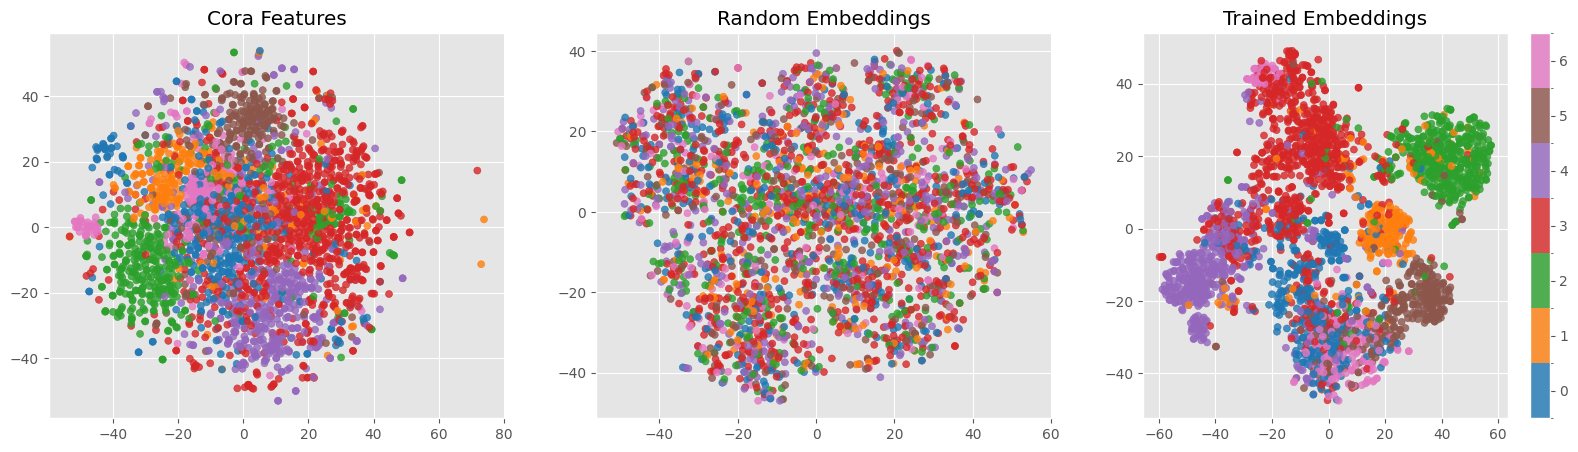

In [199]:
plt.style.use('ggplot')


fig, ax = plt.subplots(1,3, figsize=(20, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', 
          '#d62728', '#9467bd', '#8c564b', '#e377c2']
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(colors)
bounds = np.arange(8) - 0.5
norm = BoundaryNorm(bounds, cmap.N)

modes = ['Cora Features', 'Random Embeddings', 'Trained Embeddings']
embeddings_per_mode = [graph.x, embeddings_untrained, embeddings]
for i, mode in enumerate(modes):
    data_2d = tsne.fit_transform(embeddings_per_mode[i])
    scatter = ax[i].scatter(data_2d[:, 0], data_2d[:, 1],
                        c=labels, cmap=cmap, norm=norm,
                        s=25, alpha=0.8)
    
    ax[i].set_title(mode)

cbar = fig.colorbar(scatter, ticks=np.arange(7))
plt.grid(True)
plt.show()
